In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
from svgutils.compose import Figure, SVG, Unit
from svgutils.transform import fromfile, SVGFigure
from IPython.display import SVG as DisplaySVG, display


In [2]:
def setZero(c,G,c0, G0=0):
    zero_ndx=min(range(len(c)), key=lambda i: abs(c[i]-c0)) #np.where(c==c0)[0][0]
    G_offset=[G[i]-G[zero_ndx]+G0 for i in range(len(G))]
    return G_offset

def coulomb(r, q1, q2, eps=78.5):
    e = 1.6e-19
    nm = 1e-9
    A = 6.022e23
    k_kCal = 1/(4 * np.pi * 8.854187817e-12) / 4.184e3
    const = k_kCal * e**2 / nm * A
    return const * q1 * q2 / (eps * r)

def loadPMF(file):
    try:
        return np.loadtxt(file)
    except Exception:
        return f"Missing file: {file}"

In [3]:
rMaxList = {"ace-ca":1.2, "ace-na":1.2, "ca-cl":1.0, "na-cl":1.0, 
         "dma-ca":1.2, "dma-na":1.2,
         "na-ca":1.0, "ace-cl":1.2, "ace-dma":1.2, "dma-cl":1.0,
         "dma-dma":1.2, "ca-ca":1.5, "cl-cl":1.0, "na-na":1.0, "ace-ace":1.2}
sysList = list(rMaxList.keys())

atomNameQ = {"ca": ["Ca", 2],
             "cl": ["Cl", -1],
             "na": ["Na", 1],
             "dma": ["DMA", 0],
             "ace": ["ACE", -1]} 

pmfFileColor={"DFT":["dft", "k"], 
              "MM":["mm", "tab:blue"], 
              "GB":["gb", "thistle"],
              "GB*":["gbx", "orange"], 
              "GB**":["gbxx", "orange"], 
              "MM*":["mmx", "orange"]}

plots = {"GB*":["GB*", "MM", "GB"][::-1],
         "GB**":["GB**", "DFT", "MM", "GB"][::-1],
         "MM*":["MM*", "DFT", "MM"][::-1]}
plotNames = list(plots.keys())

def get_readable_sysname(sysName):
    atoms = sysName.split('-')
    return ' -- '.join([atomNameQ[a][0] for a in atoms])

def makeCoulombData(rmin, rmax, sysName):
    r = np.linspace(rmin, rmax, 100)
    [q1, q2] = [atomNameQ[a][1] for a in sysName.split('-')]
    coulombData = setZero(r, np.array([coulomb(x, q1, q2) for x in r]), 1.2)
    return r, coulombData

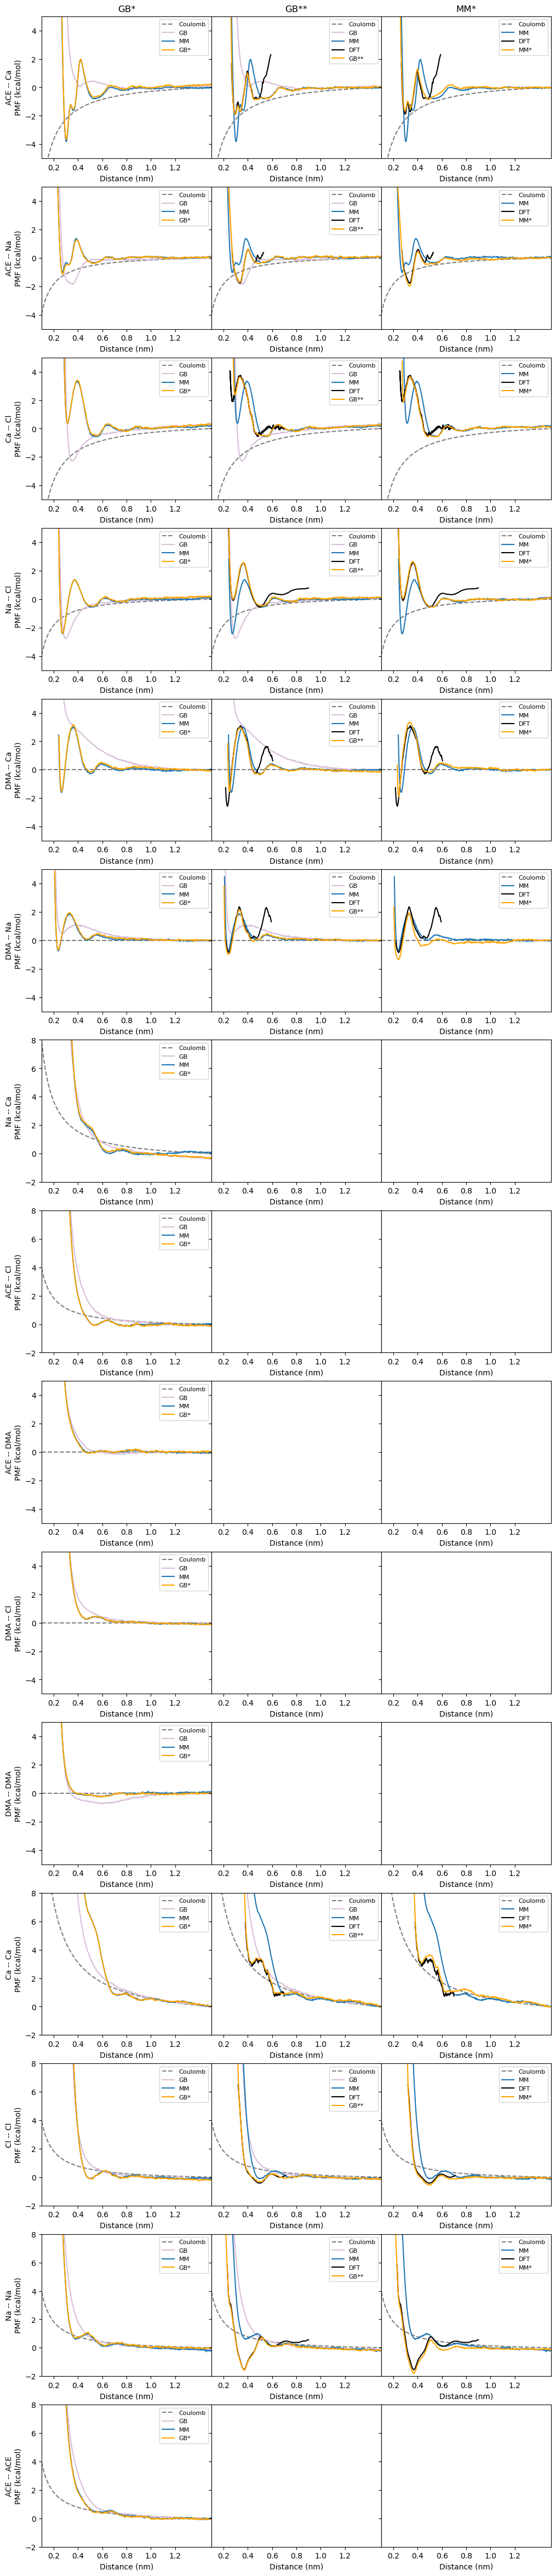

In [11]:
fig, ax = plt.subplots(len(sysList), len(plots), figsize=(12, 60), sharex=False)

for i, sysName in enumerate(sysList):
    for j, plotName in enumerate(plotNames):
        r, coulombData = makeCoulombData(0.1, 1.5, sysName)
        coulombData = setZero(r, coulombData, 1.5)

        # Row and Column Labels
        if i == 0: ax[i, j].set_title(plotName)
        if i == len(sysName)-2: ax[i, j].set_xlabel("Distance (nm)")

        # Set axis limits
        if coulombData[0] > 0: ax[i, j].set_ylim(-2,8)
        else: ax[i, j].set_ylim(-5, 5)
        ax[i, j].set_xlim(0.1, 1.5)
        
        # Set ticks
        if j == 0: ax[i, j].set_ylabel(f"{get_readable_sysname(sysName)}\nPMF (kcal/mol)")
        if j != 0: ax[i, j].tick_params(labelleft=False)

        ax[i,j].set_xticks([0.2, 0.4, 0.6, 0.8, 1.0, 1.2])
        ax[i, j].set_xlabel("Distance (nm)")

        # Skip if no PMF data
        file = f"data/{sysName}/pmf-{pmfFileColor[plotName][0]}.dat"
        if not os.path.isfile(file): 
            # ax[i, j].set_xticks([])
            # ax[i, j].set_xlabel("")
            continue
        
        ax[i, j].plot(r, coulombData, label="Coulomb", color="tab:grey", linestyle="--")

        for pmfName in plots[plotName]:
            pmfKey = pmfFileColor[pmfName][0]
            pmfColor = pmfFileColor[pmfName][1]

            file = f"data/{sysName}/pmf-{pmfKey}.dat"
            data = loadPMF(file)
            if isinstance(data, str): 
                print('NOT FOUND:', file)
                continue # Skip if file not found or unreadable

            r = data[:, 0]
            w = data[:, 1]
            ax[i, j].plot(r, w, label=pmfName, color=pmfColor)

        ax[i, j].legend(loc="upper right", fontsize=8, bbox_to_anchor=(1.0, 1.0))

fig.subplots_adjust(hspace=0.2, wspace=0.0)
# plt.savefig("pmf/pmf-plot.svg", bbox_inches='tight', dpi=300)
plt.show()

In [ ]:
#single plot for debugging
sysName = "ace-ca"
plotName = "GB*"
r, coulombData = makeCoulombData(0.1, 1.5, sysName)
coulombData = setZero(r, coulombData, 1.5)

# Row and Column Labels
if i == 0: ax[i, j].set_title(plotName)
if i == len(sysName)-2: ax[i, j].set_xlabel("Distance (nm)")

# Set axis limits
if coulombData[0] > 0: ax[i, j].set_ylim(-2,8)
else: ax[i, j].set_ylim(-5, 5)
ax[i, j].set_xlim(0.1, 1.5)

# Set ticks
if j == 0: ax[i, j].set_ylabel(f"{get_readable_sysname(sysName)}\nPMF (kcal/mol)")
if j != 0: ax[i, j].tick_params(labelleft=False)

ax[i,j].set_xticks([0.2, 0.4, 0.6, 0.8, 1.0, 1.2])
ax[i, j].set_xlabel("Distance (nm)")

# Skip if no PMF data
file = f"pmf/{sysName}-{pmfFileColor[plotName][0]}.dat"

ax[i, j].plot(r, coulombData, label="Coulomb", color="tab:grey", linestyle="--")

for pmfName in plots[plotName]:
    pmfKey = pmfFileColor[pmfName][0]
    pmfColor = pmfFileColor[pmfName][1]

    file = f"data/{sysName}-{pmfKey}.dat"
    data = loadPMF(file)
    if isinstance(data, str): 
        print('NOT FOUND:', file)


NOT FOUND: pmf/ace-ca-gb.dat
NOT FOUND: pmf/ace-ca-mm.dat
NOT FOUND: pmf/ace-ca-gbx.dat


Figure size: 378 x 1530
NOT FOUND: ace-ca/pmfs/ace-ca-t3p-obc1-diff-fill2.svg
NOT FOUND: ace-ca/pmfs/ace-ca-blypd-t3p-obc1-diff-fill2.svg
NOT FOUND: ace-ca/pmfs/ace-ca-blypd-t3p-diff-fill2.svg
NOT FOUND: ace-na/pmfs/ace-na-t3p-obc1-diff-fill2.svg
NOT FOUND: ace-na/pmfs/ace-na-blypd-t3p-obc1-diff-fill2.svg
NOT FOUND: ace-na/pmfs/ace-na-blypd-t3p-diff-fill2.svg
NOT FOUND: ca-cl/pmfs/ca-cl-t3p-obc1-diff-fill2.svg
NOT FOUND: ca-cl/pmfs/ca-cl-blypd-t3p-obc1-diff-fill2.svg
NOT FOUND: ca-cl/pmfs/ca-cl-blypd-t3p-diff-fill2.svg
NOT FOUND: na-cl/pmfs/na-cl-t3p-obc1-diff-fill2.svg
NOT FOUND: na-cl/pmfs/na-cl-blypd-t3p-obc1-diff-fill2.svg
NOT FOUND: na-cl/pmfs/na-cl-blypd-t3p-diff-fill2.svg
NOT FOUND: dma-ca/pmfs/dma-ca-t3p-obc1-diff-fill2.svg
NOT FOUND: dma-ca/pmfs/dma-ca-blypd-t3p-obc1-diff-fill2.svg
NOT FOUND: dma-ca/pmfs/dma-ca-blypd-t3p-diff-fill2.svg
NOT FOUND: dma-na/pmfs/dma-na-t3p-obc1-diff-fill2.svg
NOT FOUND: dma-na/pmfs/dma-na-blypd-t3p-obc1-diff-fill2.svg
NOT FOUND: dma-na/pmfs/dma-na

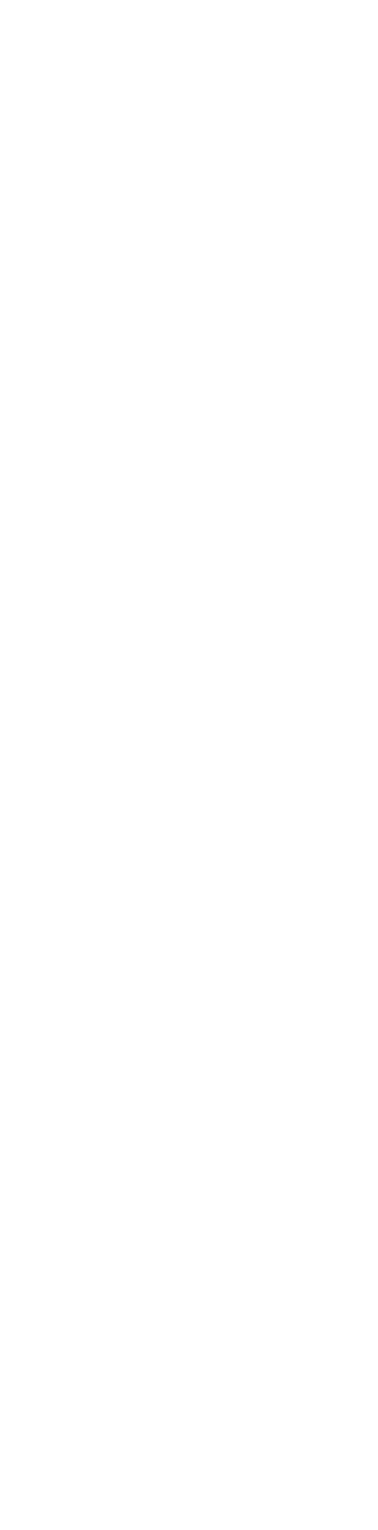

In [10]:
w,h = 126, 102
nrows, ncols = len(sysList), len(plotNames)
fig_width = f"{ncols * w }"
fig_height = f"{nrows * h}"
print(f"Figure size: {fig_width} x {fig_height}")

svgElements = []
for i, sysName in enumerate(sysList):
    for j, plotName in enumerate(plotNames):
        svgFile = f"{sysName}/pmfs/{sysName}-{pmfFileColor[plotName][0]}-diff-fill2.svg"
        if not os.path.exists(svgFile): 
            print('NOT FOUND:', svgFile)
            svgElements.append(SVG('blank.svg'))
            continue

        svgElements.append(SVG(svgFile).scale(0.3))
        # print(f"Adding {svgFile} at ({y}, {x})")
        
Figure(fig_width, fig_height, *svgElements).tile(ncols, nrows).save("pmf-diff-final/pmfs-diff-fill2-grid.svg")
display(DisplaySVG("pmf-diff-final/pmfs-diff-fill2-grid.svg"))
